In [35]:
# Import the clean_sac_file function from the previous example
from obspy import read, Trace, Stream
from obspy.signal.filter import bandpass
import numpy as np

def clean_sac_file(input_file, output_file, freq_min = 2.0, freq_max = 4.3, time_pad = 10.001):
    """
    Applies a bandpass filter to a SAC file to clean noise.
    Inputs:
    - input_file: path to the input SAC file
    - output_file: path to the output SAC file
    - freq_min: minimum frequency of the passband in Hz
    - freq_max: maximum frequency of the passband in Hz
    """
    # Read in the SAC file as an ObsPy Trace object
    trace = read(input_file)[0]
    # trace.plot()
    
    # Apply a bandpass filter to the trace
    trace_filtered = trace.copy()
    t = trace_filtered.stats.starttime

    if t + time_pad > trace_filtered.stats.endtime:
        return None
    
    trace_filtered = trace_filtered.trim(t + time_pad, trace_filtered.stats.endtime) 
    # trace_filtered = trace_filtered.trim(t, trace_filtered.stats.endtime)
    # trace_filtered.data = np.concatenate((np.zeros(750), trace_filtered.data))
    
    trace_filtered.data = bandpass(trace_filtered.data, freqmin=freq_min, freqmax=freq_max, df=trace_filtered.stats.sampling_rate)
    # trace_filtered = trace_filtered.trim(t + time_pad, trace_filtered.stats.endtime)
    # trace_filtered.plot()

    return trace_filtered

In [41]:
import os
import shutil
from obspy import read, Trace, Stream

os.makedirs("class0") # yok
os.makedirs("class1") # 1 seviye 500
os.makedirs("class2") # 2 seviye 1000
os.makedirs("class3") # 3 seviye 2000
os.makedirs("class4") # 4 seviye 4000
os.makedirs("class5") # 5 seviye 8000
os.makedirs("class6") # 6 seviye 0

# Define the directory path
dir_path = './'
orderdata = '201901'

c = 0

clean_files = []

for i, folder_month in enumerate(os.listdir(dir_path)):

    if not os.path.isfile(dir_path + folder_month):
        print(folder_month)

        for j, eartq in enumerate(os.listdir(dir_path + folder_month)):

            if not os.path.join(dir_path, folder_month, eartq).format().__contains__("BHZ"):
                continue
            
            date = str(i) + "_" + str(j) + "_"
            
            # c = c + 1
            # continue

            # Define the input and output file paths
            input_file = dir_path + folder_month + '/' + eartq
            output_file = orderdata + date + eartq.replace('(', '').replace(')', '').replace('=', '').replace('KO', 'SAC')


            file_name = dir_path + folder_month + '/' + eartq


            if clean_files.__contains__(file_name):
                continue

            trace_filtered = clean_sac_file(input_file, output_file)
            if trace_filtered is None:
                continue

            clean_files.append(file_name)

            # if trace_filtered.stast.endtime - trace_filtered.stats.starttime < 15:
            #     continue

            min_val = min(trace_filtered.data[150:])
            max_val = max(trace_filtered.data[300:])

            max_value_index = np.argmax(trace_filtered.data[300:])
            # get the 1000 padding centered max index
            trace_filtered.data = trace_filtered.data[max_value_index - 2000: max_value_index + 2000]
           
            print(f"min: {min_val} max: {max_val}")
            print(file_name)
            # if max_val > 16000:
            #     trace_filtered.write('./class6/' + output_file, format='SAC')
            #     # shutil.copy(file_name, './class6/' + eartq + '_original.sac')

            if max_val < 500:
                trace_filtered.write('./class0/' + output_file, format='SAC')
                # shutil.copy(file_name, './class0/' + eartq + '_original.sac')
            elif max_val < 1000:
                trace_filtered.write('./class1/' + output_file, format='SAC')
                # shutil.copy(file_name, './class1/' + eartq + '_original.sac')
            elif max_val < 2000:
                trace_filtered.write('./class2/' + output_file, format='SAC')
                # shutil.copy(file_name, './class2/' + eartq + '_original.sac')
            elif max_val < 4000:
                trace_filtered.write('./class3/' + output_file, format='SAC')
                # shutil.copy(file_name, './class3/' + eartq + '_original.sac')
            elif max_val < 8000:
                trace_filtered.write('./class4/' + output_file, format='SAC')
                # shutil.copy(file_name, './class4/' + eartq + '_original.sac')
            elif max_val < 16000:
                trace_filtered.write('./class5/' + output_file, format='SAC')
                # shutil.copy(file_name, './class5/' + eartq + '_original.sac')
            else:
                trace_filtered.write('./class6/' + output_file, format='SAC')
                # shutil.copy(file_name, './class6/' + eartq + '_original.sac')

print(c)

20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7
min: -11730.978864658742 max: 12872.673938979624
./20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7/SIMA.BHZ.KO
min: -119531.34189957651 max: 4953.246999470463
./20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7/CAVI.BHZ.KO
min: -182.1440794059602 max: 182.1007217320182
./20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7/KULA.BHZ.KO
min: -154.94947487762752 max: 28.97603822696667
./20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7/YLV.BHZ.KO
min: -1561.2404242951088 max: 1535.0872967819503
./20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7/GEDZ.BHZ.KO
min: -133.33030002095842 max: 70.00479352975184
./20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7/TVSB.BHZ.KO
min: -162.65604240998616 max: 148.1232196024465
./20190120_13205939.14-29.06Ke-AHLATLICESME-SIMAV-KUTAHYA_M_1_7/ARMT.BHZ.KO
20190105_02060839.13-29.07Ke-SOGUT-SIMAV-KUTAHYA_M_2_0
min: -27810.627

20190113_44_TVSB.BHZ.SAC


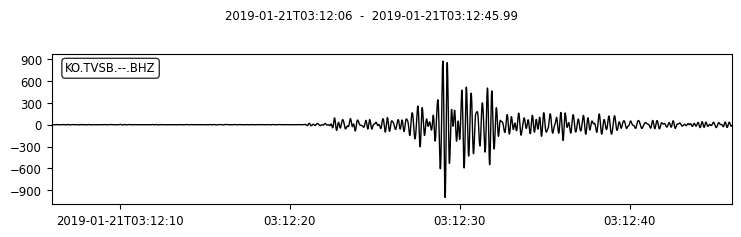

4000
20190114_8_GEDZ.BHZ.SAC


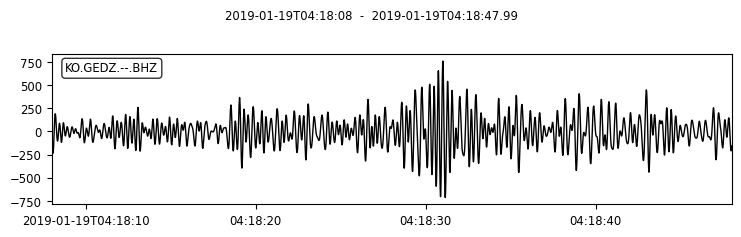

4000
20190116_15_GEDZ.BHZ.SAC


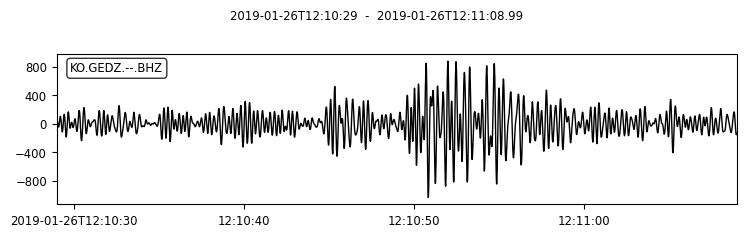

4000
20190119_37_TVSB.BHZ.SAC


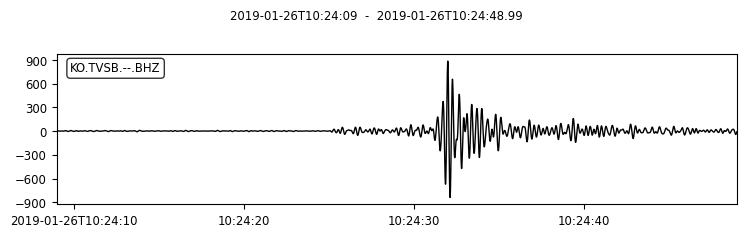

4000
20190119_38_ARMT.BHZ.SAC


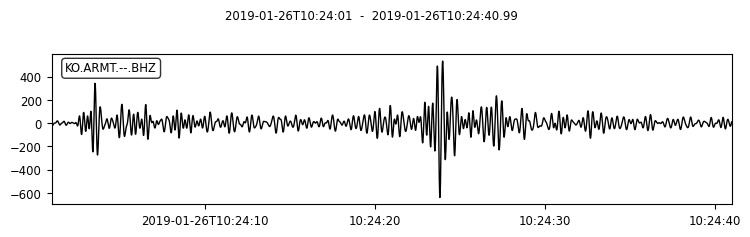

4000
20190119_50_MDNY.BHZ.SAC
20190119_9_KULA.BHZ.SAC


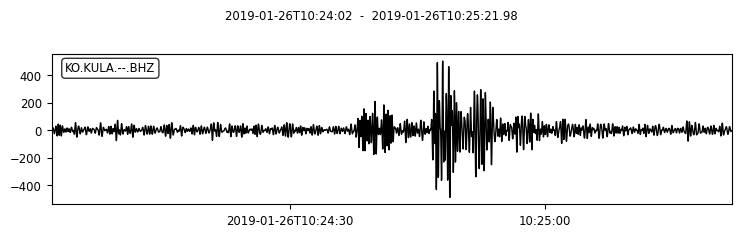

4000
2019011_12_KULA.BHZ.SAC


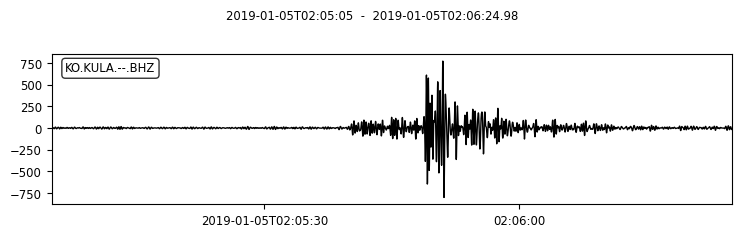

4000
2019011_53_ARMT.BHZ.SAC


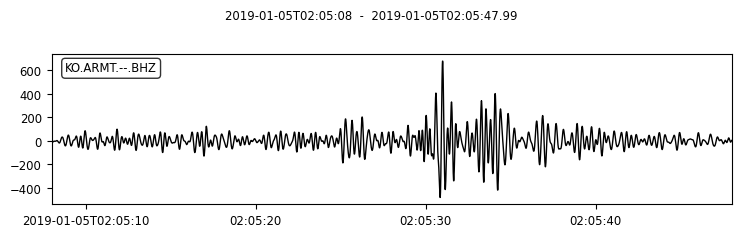

4000
20190122_11_KULA.BHZ.SAC


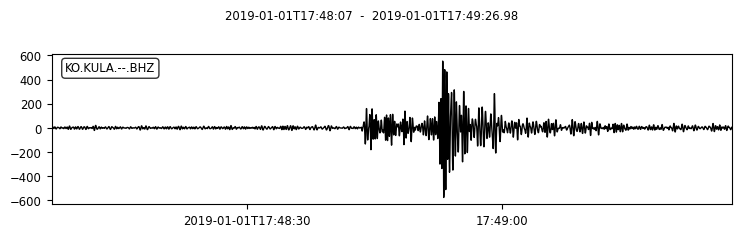

4000
20190122_49_ARMT.BHZ.SAC


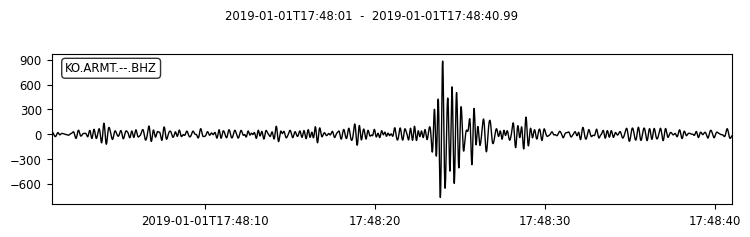

4000
20190122_66_MDNY.BHZ.SAC


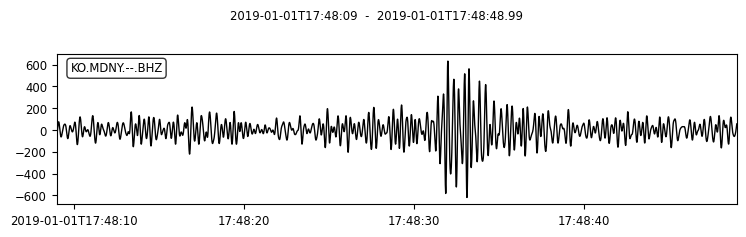

4000
20190123_25_GEDZ.BHZ.SAC


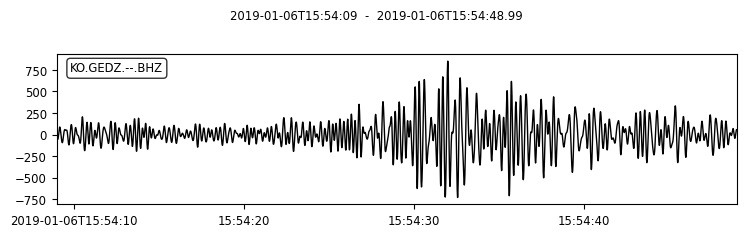

4000
2019014_0_2019011_12_KULA.BHZ.SAC
2019014_1_2019011_53_ARMT.BHZ.SAC
2019019_60_TVSB.BHZ.SAC


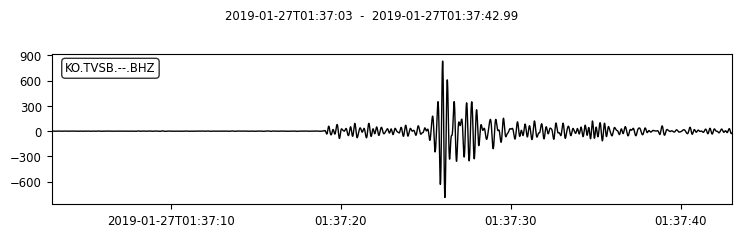

4000
2019019_63_ARMT.BHZ.SAC


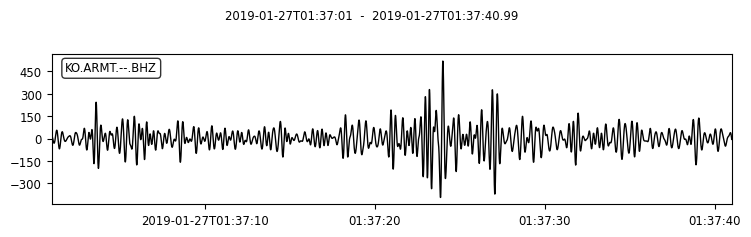

4000


In [56]:

#  read sac file

from obspy import read, Trace, Stream

path = "./"
folder_class = "class1"

files = []

for j, file in enumerate(os.listdir(path= path + folder_class)):
    files.append(file)

files = sorted(files)

for i, file in enumerate(files):
    print(file)
    trace = read(path + folder_class + "/" + file)[0]
    if len(trace.data) == 4000:
        trace.plot()
        print(len(trace.data))
        ix = input("Press Enter to continue...")
        if ix == 'q':
            break


308.99


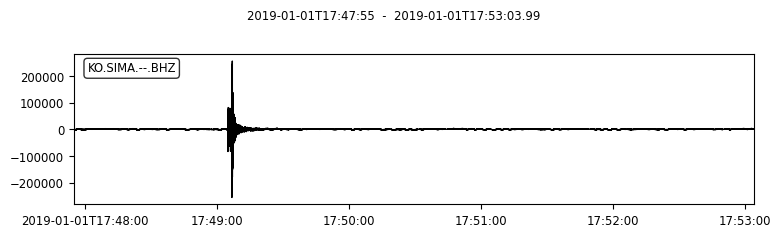

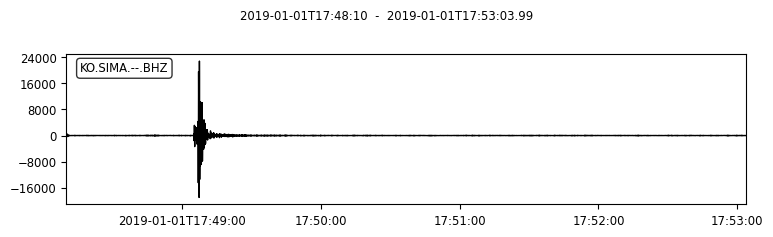

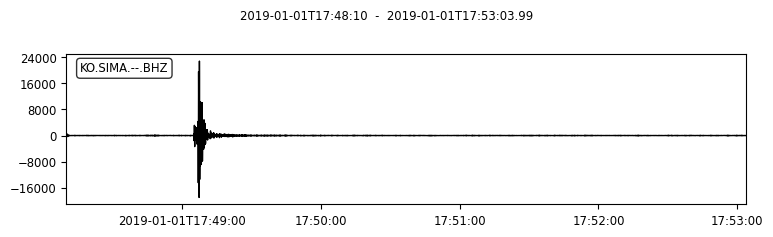

In [15]:
from obspy import read, Trace, Stream

path = "/home/mbulucay/Desktop/GradProject/2019/201901/20190101_17490239.14-29.07Ke-SOGUT-SIMAV-(KUTAHYA).M=2.0/SIMA.BHZ.KO"

trace = read(path)[0]
print(trace.stats.endtime - trace.stats.starttime)
trace.plot()

filtered = clean_sac_file(path, "")
filtered.plot()


In [ ]:
import os

# Define the directory path
dir_path = './'

for folder_month in os.listdir(dir_path):

    if not os.path.isfile(dir_path + folder_month):
        print(folder_month)

        for eartq in os.listdir(dir_path + folder_month):
            print(f"    {eartq}")
            
            for sac_file in os.listdir(dir_path + folder_month + '/' + eartq):
                print(f"        {sac_file}")
                # Define the input and output file paths
                input_file = dir_path + folder_month + '/' + eartq + '/' + sac_file
                output_file = dir_path + folder_month + '/' + eartq + '/' + sac_file[:-4] + '_filtered.sac'

                # Apply the clean_sac_file function
                trace_filtered = clean_sac_file(input_file, output_file)
                trace_filtered.plot()
                # trace_filtered.write(output_file, format='SAC')
            
                ix = input("Press Enter to continue...")

                if ix == 'q':
                    break




20190110_0_SIMA.BHZ.SAC_filtered.sac


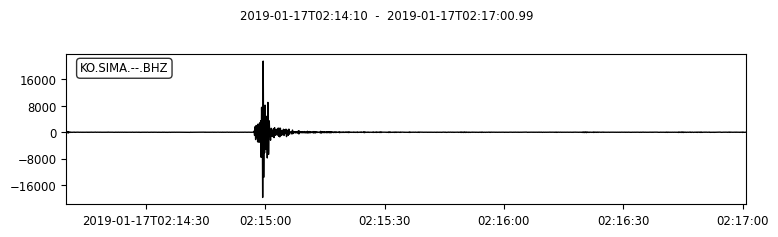

20190110_0_SIMA.BHZ.SAC_filtered.sac_original.sac


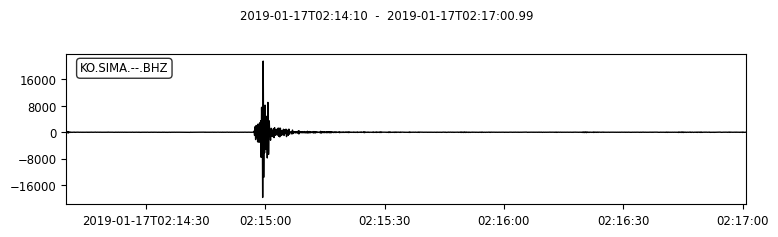

In [ ]:

# #  read sac file


# from obspy import read, Trace, Stream

# path = "./"
# folder_class = "class6"

# for j, file in enumerate(os.listdir(path= path + folder_class)):
#     print(file)
#     trace = read(path + folder_class + "/" + file)[0]
#     trace.plot()
#     ix = input("Press Enter to continue...")
#     if ix == 'q':
#         break



